In [63]:
import numpy as np 
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [64]:
data=pd.read_csv("train.csv")
data.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


<Axes: >

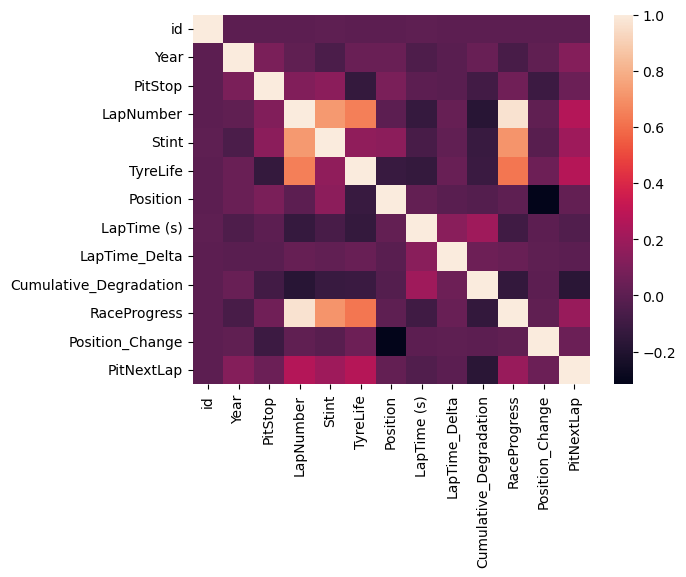

In [65]:
sns.heatmap(data.corr(numeric_only=True))

In [66]:
data['PitNextLap'].value_counts()

PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64

In [67]:
data.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

In [68]:
data.columns.tolist()

['id',
 'Driver',
 'Compound',
 'Race',
 'Year',
 'PitStop',
 'LapNumber',
 'Stint',
 'TyreLife',
 'Position',
 'LapTime (s)',
 'LapTime_Delta',
 'Cumulative_Degradation',
 'RaceProgress',
 'Position_Change',
 'PitNextLap']

In [69]:
# Define feature engineering function


# Tire effeciency
data["Tire_Life_Ratio"]=(data["TyreLife"]/data["LapNumber"])

# "Are the tires old AND getting slower


data["Tyre_health"]=(data["TyreLife"] * data["LapTime_Delta"])



# Wear Acumulated per lap

data["accumulated_per_lap"]=(data["TyreLife"] * data["Cumulative_Degradation"])

# tires survive until the finish

data["Tires_survivel"]=(data["TyreLife"] * data["RaceProgress"])

# Tire degradation pressure

data["TireTempInteraction"]=(data["TyreLife"] * data["RaceProgress"])



data["High_pit_prob"]=(data["LapTime_Delta"] + data["Cumulative_Degradation"])





data["RacePositionPressure"] = (data["LapNumber"] * data["Position"])

In [70]:
data.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,...,RaceProgress,Position_Change,PitNextLap,Tire_Life_Ratio,Tyre_health,accumulated_per_lap,Tires_survivel,TireTempInteraction,High_pit_prob,RacePositionPressure
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,...,0.714286,5.0,1.0,0.780000,-294.996,819.741,27.857143,27.857143,13.455,400
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,...,0.346154,-3.0,0.0,0.259259,-228.319,-1562.449,2.423077,2.423077,-255.824,108
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,...,0.819444,3.0,1.0,0.372881,-165.880,-2211.638,18.027778,18.027778,-108.069,767
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,...,0.076923,0.0,0.0,1.000000,-14.648,-14.648,0.153846,0.153846,-14.648,14
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,...,0.361111,3.0,0.0,0.230769,53.790,-84.834,2.166667,2.166667,-5.174,52


In [86]:
data=data.drop(columns="id",axis=1)
data=data.drop(columns="Race",axis=1)
data=data.drop(columns="Driver",axis=1)




KeyError: "['id'] not found in axis"

In [72]:
le = LabelEncoder()

data['Compound'] = le.fit_transform(data['Compound'])

In [73]:
data

,Compound,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,Tire_Life_Ratio,Tyre_health,accumulated_per_lap,Tires_survivel,TireTempInteraction,High_pit_prob,RacePositionPressure
0,0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0,0.780000,-294.996,819.741,27.857143,27.857143,13.455,400
1,0,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0,0.259259,-228.319,-1562.449,2.423077,2.423077,-255.824,108
2,0,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0,0.372881,-165.880,-2211.638,18.027778,18.027778,-108.069,767
3,2,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0,1.000000,-14.648,-14.648,0.153846,0.153846,-14.648,14
4,0,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0,0.230769,53.790,-84.834,2.166667,2.166667,-5.174,52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439135,2,2023,0,49,2,8.0,17,92.638,-0.076,-15.859,0.859649,0.0,0.0,0.163265,-0.608,-126.872,6.877193,6.877193,-15.935,833
439136,2,2023,0,49,2,5.0,1,85.890,-0.083,-4.907,0.859649,0.0,0.0,0.102041,-0.415,-24.535,4.298246,4.298246,-4.990,49
439137,2,2023,0,49,2,18.0,1,91.644,-0.182,-56.371,0.942308,0.0,0.0,0.367347,-3.276,-1014.678,16.961538,16.961538,-56.553,49
439138,0,2023,0,48,3,10.0,1,89.947,-0.001,-20.721,0.827586,1.0,0.0,0.208333,-0.010,-207.210,8.275862,8.275862,-20.722,48


In [74]:
x=data.drop(columns="PitNextLap",axis=1)
y=data["PitNextLap"]


In [75]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,stratify=y,random_state=7)

In [76]:
# using XGboost

from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [77]:
x_train_prediction=model.predict(x_train)
train_data_accuracy=accuracy_score(x_train_prediction,y_train)
train_data_accuracy

0.9006467185863278

In [78]:
#Accuracy for test data
x_test_prediction=model.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)
test_data_accuracy

0.892813225850526

In [79]:
test=pd.read_csv("test.csv")
test
    

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188160,627300,D171,MEDIUM,Australian Grand Prix,2024,1,14,1,14.0,4,83.879,-16.919,-87.767,0.179487,-2.0
188161,627301,RUS,SOFT,Pre-Season Testing,2025,0,60,3,26.0,4,95.727,7.920,-36.485,0.789474,-3.0
188162,627302,D112,MEDIUM,Hungarian Grand Prix,2022,0,28,2,21.0,7,85.058,-14.180,-0.339,0.388889,3.0
188163,627303,D349,MEDIUM,Monaco Grand Prix,2024,0,20,2,15.0,7,80.074,-19.004,-37.967,0.256410,0.0


In [80]:
# Tire effeciency
test["Tire_Life_Ratio"]=(test["TyreLife"]/test["LapNumber"])

# "Are the tires old AND getting slower


test["Tyre_health"]=(test["TyreLife"] * test["LapTime_Delta"])



# Wear Acumulated per lap

test["accumulated_per_lap"]=(test["TyreLife"] * test["Cumulative_Degradation"])

# tires survive until the finish

test["Tires_survivel"]=(test["TyreLife"] * test["RaceProgress"])

# Tire degradation pressure

test["TireTempInteraction"]=(test["TyreLife"] * test["RaceProgress"])



test["High_pit_prob"]=(data["LapTime_Delta"] + test["Cumulative_Degradation"])





test["RacePositionPressure"] = (test["LapNumber"] * test["Position"])

In [81]:
le = LabelEncoder()

test['Compound'] = le.fit_transform(test['Compound'])

In [82]:
test=test.drop(columns="id",axis=1)
test=test.drop(columns="Race",axis=1)
test=test.drop(columns="Driver",axis=1)


In [83]:
print(test.columns.tolist())
print(x.columns.tolist())

['Compound', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'Tire_Life_Ratio', 'Tyre_health', 'accumulated_per_lap', 'Tires_survivel', 'TireTempInteraction', 'High_pit_prob', 'RacePositionPressure']
['Compound', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'Tire_Life_Ratio', 'Tyre_health', 'accumulated_per_lap', 'Tires_survivel', 'TireTempInteraction', 'High_pit_prob', 'RacePositionPressure']


In [84]:
preds = model.predict(test)
print(preds[:10])
test_original = pd.read_csv("test.csv")

[0 0 0 0 1 0 0 0 0 0]


In [85]:

submission = pd.DataFrame({
    "id": test_original["id"],
    "PitNextLap": preds
})

submission.to_csv("submission.csv", index=False)